In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Name': [
        'Pam','Jane','Alice','Bob','Pam','Jade','Joanne','Kim','Sam','Eli',
        'Joe','Anna','Dan','Susan','Pamela','Susy','Ruth','Dan','Joanne',
        'Clark','Alissa','Norma','Anthony','Eli','Tony','Alice','Samantha',
        'Amanda','Jenny','Pam','Anthony','Sam','Penny','Jimmy','Tim','Fran',
        'Jenny','Joe','Timmy','Sammy','Anna','Pam','Kim'
    ],

    'Age': [
        25,None,22,22,25,40,25,33,40,None,22,36,43,46,None,41,30,43,25,
        44,36,51,30,21,None,22,50,28,36,25,30,40,44,38,40,47,36,22,44,
        57,36,25,33
    ],

    'Salary': [
        70200,65000,71350,None,71250,None,120000,71568,None,80100,
        62000,72456,None,66000,77421,126001,72114,None,125600,
        76982,77421,921000,61000,77421,66200,70000,77421,66100,
        801423,70000,66000,None,77421,65000,70050,76000,75000,
        66000,68000,66000,None,86548,546222
    ],

    'Join_Date': [
        '1/15/2023','8/1/2022','5/20/2021','1/15/2023','1/15/2023',
        '1/15/2023','1/16/2023','8/30/2021','9/5/2022','3/4/2022',
        '10/9/2022','4/6/2022','1/15/2023','5/3/2022','4/2/2023',
        '2/2/2023','9/5/2022','5/3/2022','1/16/2023','1/28/2023',
        '10/5/2022','2/4/2021','8/6/2021','3/4/2022','5/18/2023',
        '5/20/2021','1/15/2023','8/23/2021','9/15/2021','1/15/2023',
        '8/6/2021','9/5/2022','9/4/2022','10/3/2024','10/4/2023',
        '2/5/2023','9/15/2021','10/9/2022','9/24/2023','10/1/2022',
        '4/6/2022','1/15/2023','8/30/2021'
    ],

    'Department': [
        'HR','Finance','HR','IT','HR','Finance','IT','HR','IT','HR',
        'Finance','HR','HR','Finance','HR','IT','HR','HR','IT','HR',
        'HR','IT','Finance','HR','Finance','HR','HR','Finance','IT','HR',
        'Finance','IT','HR','HR','HR','IT','IT','Finance','IT','Finance',
        'HR','HR','HR'
    ]
}

df = pd.DataFrame(data)

print("Original Dataset:")
display(df)

print("\nDataset Shape:", df.shape)

Original Dataset:


,Name,Age,Salary,Join_Date,Department
0,Pam,25.0,70200.0,1/15/2023,HR
1,Jane,NaN,65000.0,8/1/2022,Finance
2,Alice,22.0,71350.0,5/20/2021,HR
3,Bob,22.0,NaN,1/15/2023,IT
4,Pam,25.0,71250.0,1/15/2023,HR
5,Jade,40.0,NaN,1/15/2023,Finance
6,Joanne,25.0,120000.0,1/16/2023,IT
7,Kim,33.0,71568.0,8/30/2021,HR
8,Sam,40.0,NaN,9/5/2022,IT
9,Eli,NaN,80100.0,3/4/2022,HR



Dataset Shape: (43, 5)


In [14]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nSummary Statistics:")
display(df.describe())

Missing Values:
Name          0
Age           4
Salary        7
Join_Date     0
Department    0
dtype: int64

Duplicate Rows:
1

Summary Statistics:


,Age,Salary
count,39.000000,36.000000
mean,34.692308,132729.694444
std,9.624951,196694.464572
min,21.000000,61000.000000
25%,25.000000,66175.000000
50%,36.000000,71841.000000
75%,42.000000,77421.000000
max,57.000000,921000.000000


In [15]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (42, 5)


In [16]:
# Fill missing Age values with median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Salary values with median salary
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Name          0
Age           0
Salary        0
Join_Date     0
Department    0
dtype: int64


In [17]:
df['Join_Date'] = pd.to_datetime(df['Join_Date'])

print(df.dtypes)

Name                  object
Age                  float64
Salary               float64
Join_Date     datetime64[ns]
Department            object
dtype: object


In [18]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[
    (df['Salary'] < lower_bound) |
    (df['Salary'] > upper_bound)
]

print("\nSalary Outliers:")
display(outliers[['Name', 'Salary', 'Department']])

Q1: 68500.0
Q3: 77421.0
IQR: 8921.0
Lower Bound: 55118.5
Upper Bound: 90802.5

Salary Outliers:


,Name,Salary,Department
6,Joanne,120000.0,IT
15,Susy,126001.0,IT
18,Joanne,125600.0,IT
21,Norma,921000.0,IT
28,Jenny,801423.0,IT
42,Kim,546222.0,HR


In [19]:
df['Salary'] = df['Salary'].clip(
    lower=lower_bound,
    upper=upper_bound
)

print("Salary after outlier treatment:")
display(df[['Name', 'Salary']])

Salary after outlier treatment:


,Name,Salary
0,Pam,70200.0
1,Jane,65000.0
2,Alice,71350.0
3,Bob,71841.0
4,Pam,71250.0
5,Jade,71841.0
6,Joanne,90802.5
7,Kim,71568.0
8,Sam,71841.0
9,Eli,80100.0


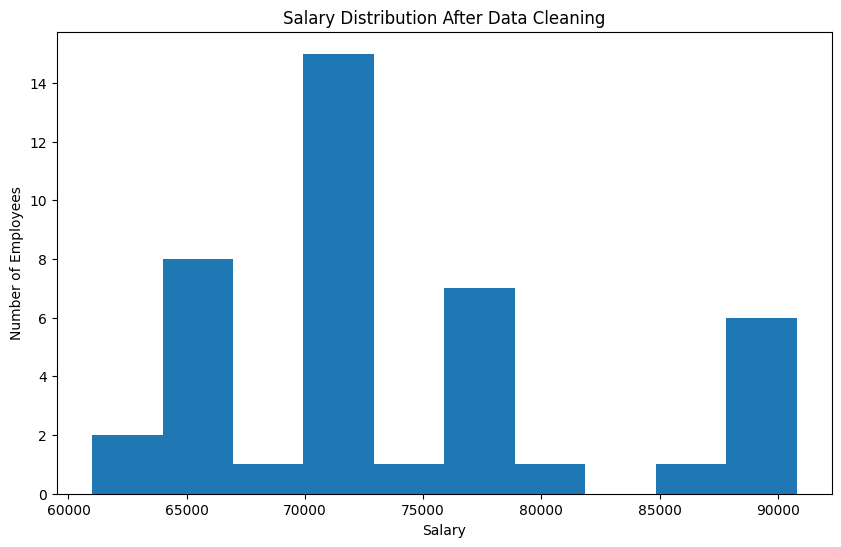

In [20]:
plt.figure(figsize=(10,6))

plt.hist(df['Salary'], bins=10)

plt.title('Salary Distribution After Data Cleaning')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')

plt.show()

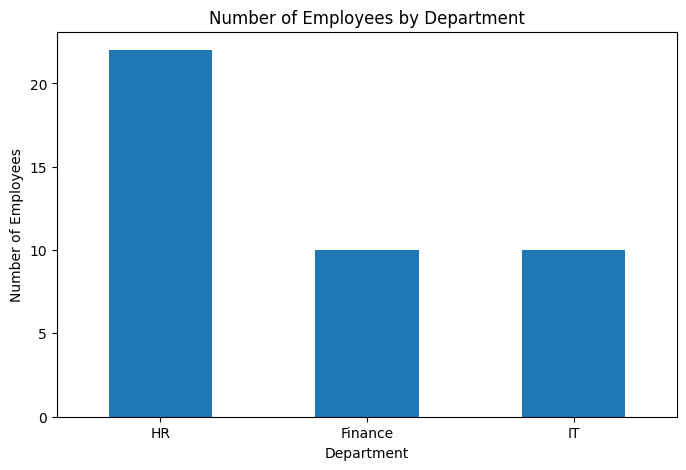

In [21]:
plt.figure(figsize=(8,5))

df['Department'].value_counts().plot(kind='bar')

plt.title('Number of Employees by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')

plt.xticks(rotation=0)
plt.show()

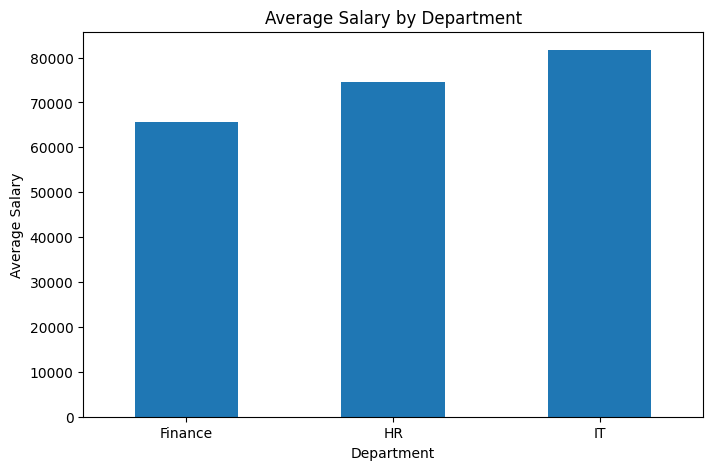

In [22]:
avg_salary = df.groupby('Department')['Salary'].mean()

plt.figure(figsize=(8,5))

avg_salary.plot(kind='bar')

plt.title('Average Salary by Department')
plt.xlabel('Department')
plt.ylabel('Average Salary')

plt.xticks(rotation=0)
plt.show()

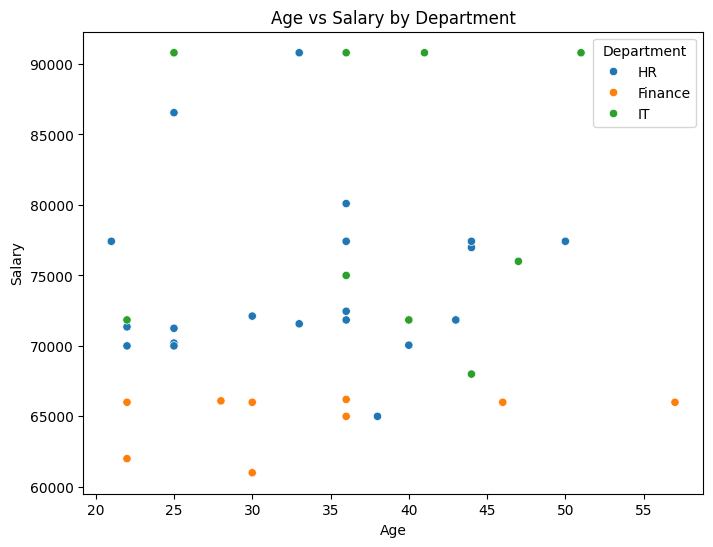

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Salary',
    hue='Department'
)

plt.title('Age vs Salary by Department')
plt.xlabel('Age')
plt.ylabel('Salary')

plt.show()

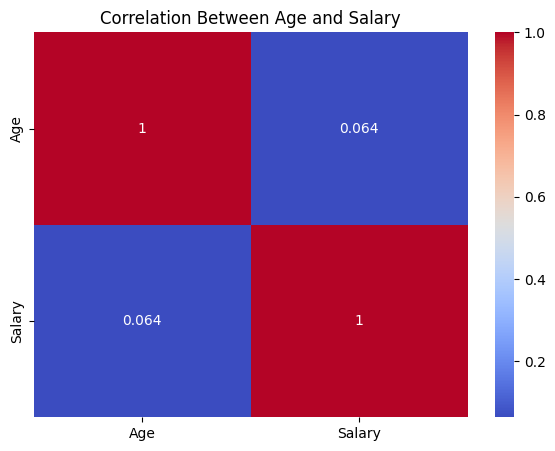

In [24]:
plt.figure(figsize=(7,5))

correlation = df[['Age', 'Salary']].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Between Age and Salary')

plt.show()

In [25]:
print("FINAL DATASET SHAPE:", df.shape)

print("\nAverage Salary by Department:")
display(df.groupby('Department')['Salary'].mean().round(2))

print("\nEmployee Count by Department:")
print(df['Department'].value_counts())

print("\nAverage Age by Department:")
display(df.groupby('Department')['Age'].mean().round(2))

print("\nOverall Average Salary:", round(df['Salary'].mean(), 2))
print("Overall Average Age:", round(df['Age'].mean(), 2))

FINAL DATASET SHAPE: (42, 5)

Average Salary by Department:


,Salary
Department,
Finance,65614.10
HR,74593.11
IT,81669.45



Employee Count by Department:
Department
HR         22
Finance    10
IT         10
Name: count, dtype: int64

Average Age by Department:


,Age
Department,
Finance,34.70
HR,33.77
IT,36.70



Overall Average Salary: 74140.1
Overall Average Age: 34.69


In [26]:
df.to_csv('cleaned_employee_dataset.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Key Findings

1. The original dataset contained missing values in the Age and Salary columns.
2. Missing numerical values were handled using median imputation.
3. Duplicate records were identified and removed.
4. Salary outliers were detected using the Interquartile Range (IQR) method.
5. Extreme salary values were capped using the IQR limits to reduce their influence on analysis.
6. The Join_Date column was converted into a standardized datetime format.
7. Department-wise analysis was performed to compare employee counts and average salaries.
8. Visualizations were used to understand salary distribution, department composition, and the relationship between age and salary.

# Conclusion

The raw employee dataset was successfully cleaned and processed using Pandas. Missing values, duplicate records, and salary outliers were handled systematically. Visualizations provided useful insights into employee demographics and salary patterns across departments.